# Boston Housing Price Prediction Using a PyTorch Neural Network

This notebook implements Boston housing price prediction with a deep neural network in PyTorch, using CUDA when available.

## Workflow and Metrics

1. Load the Boston housing dataset
2. Display the dataset with column names
3. Clean and standardize the data
4. Train a PyTorch regression model
5. Evaluate with MAE, MSE, RMSE, and R2
6. Compare against a mean baseline

In [1]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Torch version: 2.5.1+cu121
CUDA available: True
Torch CUDA version: 12.1
GPU count: 1
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_openml
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA is not available in this environment.")
    print("Install CUDA-enabled PyTorch and verify NVIDIA driver/GPU visibility.")
    print("Recommended install command:")
    print("pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
# Load Boston housing dataset
boston = fetch_openml(name="boston", version=1, as_frame=True)
data = boston.frame.copy()
data = data.rename(columns={"MEDV": "MEDV"})

feature_names = list(data.columns[:-1])
train_df = data.copy()
print("Dataset preview with column names:")
print(train_df.head())
print("\nMissing values:")
print(train_df.isnull().sum())

x = data.iloc[:, :-1].astype(np.float32).values
y = data.iloc[:, -1].astype(np.float32).values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

baseline_pred = np.full_like(y_test, y_train.mean(), dtype=np.float32)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, baseline_pred)

print("\nTrain shape:", x_train.shape, "Test shape:", x_test.shape)
print("Baseline MAE:", round(baseline_mae, 4))
print("Baseline MSE:", round(baseline_mse, 4))
print("Baseline RMSE:", round(baseline_rmse, 4))
print("Baseline R2:", round(baseline_r2, 4))

Dataset preview with column names:
      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Missing values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Train shape: (404, 13) Test shape: (102, 13)
Baseline MAE: 6.2558
Baseline MSE: 75.0454
Baseline RMSE: 8.6629
Baseline R2

In [4]:
class BostonRegressor(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


model = BostonRegressor(x_train.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(x_train_tensor, y_train_tensor), batch_size=32, shuffle=True)

history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")
early_stop_counter = 0
patience = 15

for epoch in range(1, 201):
    model.train()
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    model.eval()
    with torch.no_grad():
        val_outputs = model(torch.tensor(x_test, dtype=torch.float32).to(device))
        val_loss = criterion(val_outputs, torch.tensor(y_test, dtype=torch.float32).to(device)).item()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered")
            break

model.load_state_dict(best_state)
print("Best validation loss:", round(best_val_loss, 4))

Epoch 1: train_loss=595.3443, val_loss=511.9334
Epoch 2: train_loss=563.3442, val_loss=473.5323
Epoch 3: train_loss=507.4360, val_loss=407.3884
Epoch 4: train_loss=414.3962, val_loss=306.0157
Epoch 5: train_loss=291.5235, val_loss=182.4755
Epoch 6: train_loss=164.6936, val_loss=85.9483
Epoch 7: train_loss=84.6033, val_loss=49.3021
Epoch 8: train_loss=56.9749, val_loss=37.2872
Epoch 9: train_loss=41.4896, val_loss=30.9141
Epoch 10: train_loss=32.8713, val_loss=27.6985
Epoch 11: train_loss=27.7405, val_loss=25.8164
Epoch 12: train_loss=25.1068, val_loss=24.4879
Epoch 13: train_loss=23.3763, val_loss=23.2390
Epoch 14: train_loss=22.2079, val_loss=22.3521
Epoch 15: train_loss=21.0685, val_loss=21.5886
Epoch 16: train_loss=20.2831, val_loss=20.8591
Epoch 17: train_loss=19.5663, val_loss=20.1061
Epoch 18: train_loss=18.9071, val_loss=19.6171
Epoch 19: train_loss=18.4591, val_loss=19.1094
Epoch 20: train_loss=17.7490, val_loss=18.5687
Epoch 21: train_loss=17.3927, val_loss=18.1304
Epoch 22: t

Model MAE: 2.1703
Model MSE: 10.3739
Model RMSE: 3.2209
Model R2: 0.8585

Comparison (Baseline vs Model):
MAE  : 6.2558 -> 2.1703
MSE  : 75.0454 -> 10.3739
RMSE : 8.6629 -> 3.2209
R2   : -0.0233 -> 0.8585


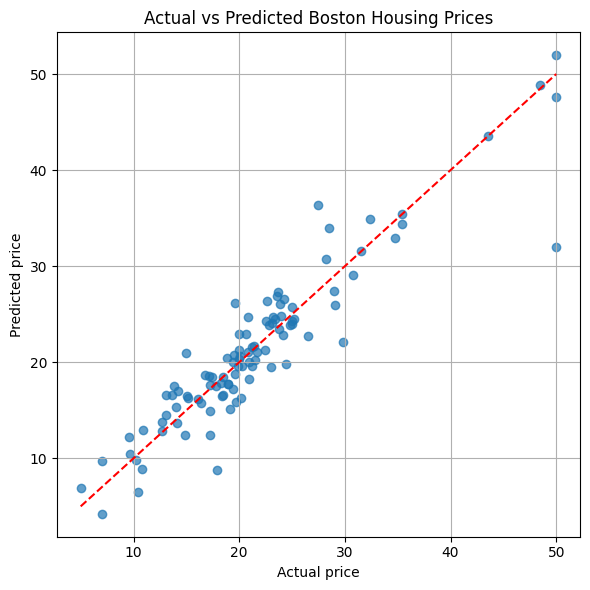

In [5]:
model.eval()
with torch.no_grad():
    y_pred = model(torch.tensor(x_test, dtype=torch.float32).to(device)).cpu().numpy()

model_mae = mean_absolute_error(y_test, y_pred)
model_mse = mean_squared_error(y_test, y_pred)
model_rmse = np.sqrt(model_mse)
model_r2 = r2_score(y_test, y_pred)

print("Model MAE:", round(model_mae, 4))
print("Model MSE:", round(model_mse, 4))
print("Model RMSE:", round(model_rmse, 4))
print("Model R2:", round(model_r2, 4))
print("\nComparison (Baseline vs Model):")
print(f"MAE  : {baseline_mae:.4f} -> {model_mae:.4f}")
print(f"MSE  : {baseline_mse:.4f} -> {model_mse:.4f}")
print(f"RMSE : {baseline_rmse:.4f} -> {model_rmse:.4f}")
print(f"R2   : {baseline_r2:.4f} -> {model_r2:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted Boston Housing Prices")
plt.grid(True)
plt.tight_layout()
plt.show()